# 🚗 Exploration des données — Véhicules Électriques & CO₂ en France

**Auteure :** Rosette-Michèle Otounga  
**Objectif :** Charger, auditer, nettoyer et préparer les 4 datasets publics avant la modélisation Prophet.

---

### Sources
| Dataset | Source | Format |
|---|---|---|
| `emissions_vehicules_ademe.csv` | ADEME | CSV, sep=`;`, ISO-8859-1 |
| `part_marche_ve.csv` | data.gouv.fr | CSV, UTF-8 |
| `intensite_carbone.csv` | Our World in Data | CSV, UTF-8 |
| `points_de_charge.csv` | data.gouv.fr | CSV, sep=`;` |

---

### Plan du notebook
1. Configuration & imports
2. Dataset ADEME — émissions CO₂ par modèle
3. Dataset intensité carbone électricité
4. Dataset part de marché VE
5. Dataset points de recharge
6. Fusions & corrélations
7. Récapitulatif & export

---
## 1. Configuration & imports

In [52]:
# ─── Librairies ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ─── Style visuel ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
COLORS = {'vert': '#2e7d32', 'bleu': '#1565c0', 'rouge': '#c62828', 'gris': '#546e7a'}

# ─── Chemins ──────────────────────────────────────────────────────────
DATA_DIR     = '../data/'
PREPARED_DIR = '../data/prepared/'
os.makedirs(PREPARED_DIR, exist_ok=True)

print('✅ Configuration prête')
print(f'   Répertoire données    : {os.path.abspath(DATA_DIR)}')
print(f'   Répertoire préparées  : {os.path.abspath(PREPARED_DIR)}')

✅ Configuration prête
   Répertoire données    : c:\Users\orose\OneDrive\Documents\omr-portfolio\side-projects\projet_ve_co2\data
   Répertoire préparées  : c:\Users\orose\OneDrive\Documents\omr-portfolio\side-projects\projet_ve_co2\data\prepared


---
## 2. Dataset ADEME — Émissions CO₂ par modèle de véhicule

In [53]:
# ─── 2.1 Chargement ───────────────────────────────────────────────────
# Encodage ISO-8859-1 : caractères français (é, è, ç...)
# Séparateur ; : standard ADEME

df_ademe_raw = pd.read_csv(
    os.path.join(DATA_DIR, 'emissions_vehicules_ademe.csv'),
    sep=';',
    encoding='ISO-8859-1'
)

print(f'Dimensions brutes : {df_ademe_raw.shape[0]:,} lignes × {df_ademe_raw.shape[1]} colonnes')
df_ademe_raw.head(3)

Dimensions brutes : 55,044 lignes × 30 colonnes


,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147,...,1505,1505,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147,...,1555,1555,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN


In [54]:
# ─── 2.2 Audit qualité ────────────────────────────────────────────────
print('━━━ AUDIT QUALITÉ — ADEME ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'Doublons : {df_ademe_raw.duplicated().sum()}')
print()

missing = df_ademe_raw.isnull().sum()
missing_pct = (missing / len(df_ademe_raw) * 100).round(1)
audit = pd.DataFrame({'Manquants': missing, '% manquant': missing_pct})
audit = audit[audit['Manquants'] > 0].sort_values('% manquant', ascending=False)
print(audit.to_string())

━━━ AUDIT QUALITÉ — ADEME ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Doublons : 7

             Manquants  % manquant
Unnamed: 27      55044       100.0
Unnamed: 28      55044       100.0
Unnamed: 29      55044       100.0
Unnamed: 26      55044       100.0
date_maj         51797        94.1
hc               45271        82.2
hcnox             9888        18.0
ptcl              2678         4.9
co_typ_1           158         0.3
nox                158         0.3
conso_mixte         34         0.1
co2                 34         0.1
conso_urb           43         0.1
conso_exurb         43         0.1
champ_v9            61         0.1


In [55]:
# ─── 2.3 Renommage des colonnes — noms explicites ─────────────────────
# On ne travaille qu'avec les colonnes utiles à l'analyse

COLONNES_ADEME = {
    'lib_mrq'          : 'marque',
    'lib_mod_doss'     : 'modele_dossier',
    'lib_mod'          : 'modele',
    'cod_cbr'          : 'type_carburant',
    'hybride'          : 'est_hybride',
    'puiss_admin_98'   : 'puissance_fiscale',
    'conso_urb'        : 'conso_urbaine',
    'conso_exurb'      : 'conso_extraurbaine',
    'conso_mixte'      : 'conso_mixte',
    'co2'              : 'co2_gkm',
    'masse_ordma_min'  : 'masse_min_kg',
    'masse_ordma_max'  : 'masse_max_kg',
    'Carrosserie'      : 'carrosserie',
    'gamme'            : 'gamme',
}

# Sélection + renommage
cols_disponibles = [c for c in COLONNES_ADEME.keys() if c in df_ademe_raw.columns]
df_ademe = df_ademe_raw[cols_disponibles].rename(columns=COLONNES_ADEME).copy()

print(f'Colonnes renommées : {len(cols_disponibles)}')
print(f'Colonnes conservées : {list(df_ademe.columns)}')

Colonnes renommées : 14
Colonnes conservées : ['marque', 'modele_dossier', 'modele', 'type_carburant', 'est_hybride', 'puissance_fiscale', 'conso_urbaine', 'conso_extraurbaine', 'conso_mixte', 'co2_gkm', 'masse_min_kg', 'masse_max_kg', 'carrosserie', 'gamme']


In [56]:
# ─── 2.4 Nettoyage ────────────────────────────────────────────────────

# Supprimer les lignes sans valeur CO₂ (variable cible)
n_avant = len(df_ademe)
df_ademe = df_ademe.dropna(subset=['co2_gkm'])
print(f'Lignes supprimées (co2 manquant) : {n_avant - len(df_ademe)}')
print(f'Dimensions finales ADEME         : {df_ademe.shape}')

Lignes supprimées (co2 manquant) : 34
Dimensions finales ADEME         : (55010, 14)


In [57]:
# ─── 2.5 Diagnostic type_carburant — valeurs réelles du fichier ───────
# Étape indispensable pour un mapping précis

print('Valeurs uniques de type_carburant (cod_cbr) :')
print(df_ademe['type_carburant'].value_counts().to_string())

print('\nValeurs uniques de est_hybride :')
print(df_ademe['est_hybride'].value_counts().to_string())

Valeurs uniques de type_carburant (cod_cbr) :
type_carburant
GO       49311
ES        5169
EH         298
GH          81
ES/GN       32
GN/ES       32
GP/ES       23
ES/GP       23
GN          21
FE          10
EE           9
GL           1

Valeurs uniques de est_hybride :
est_hybride
non    54621
oui      389


In [58]:
# ─── 2.6 Création colonne motorisation ────────────────────────────────
# Normalisation en majuscules pour capturer toutes les variantes
# (EL, El, el → même résultat)

ELEC_CODES    = {'EL', 'ELEC', 'ELECTRICITE', 'ÉLECTRICITÉ', 'BEV', 'ZEV', 'E', 'EE'}
HYBRIDE_OUI   = {'OUI', 'O', 'YES', '1', 'TRUE', 'X'}
ESSENCE_CODES = {'ES', 'ESS', 'ESSENCE', 'SP', 'SP95', 'SP98', 'E10', 'E85', 'GPL', 'GNV', 'FE'}
DIESEL_CODES  = {'GO', 'GAS', 'DIESEL', 'DI', 'GASOIL', 'GAZOLE', 'D', 'GD', 'B7', 'B10', 'XTL'}

def get_motorisation(row):
    cbr     = str(row['type_carburant']).strip().upper()
    hybride = str(row['est_hybride']).strip().upper()
    if cbr in ELEC_CODES:    return 'électrique'
    if hybride in HYBRIDE_OUI: return 'hybride'
    if cbr in ESSENCE_CODES: return 'essence'
    if cbr in DIESEL_CODES:  return 'diesel'
    return 'autre'

df_ademe['motorisation'] = df_ademe.apply(get_motorisation, axis=1)

print('Distribution motorisation :')
print(df_ademe['motorisation'].value_counts())

# Vérification : aucun VE ne doit rester dans 'autre'
autres_cbr = df_ademe[df_ademe['motorisation'] == 'autre']['type_carburant'].value_counts()
print(f'\nCodes restants en "autre" (à vérifier) :')
print(autres_cbr.head(10))

Distribution motorisation :
motorisation
diesel        49311
essence        5179
hybride         380
autre           131
électrique        9
Name: count, dtype: int64

Codes restants en "autre" (à vérifier) :
type_carburant
ES/GN    32
GN/ES    32
ES/GP    23
GP/ES    23
GN       21
Name: count, dtype: int64


In [59]:
# ─── 2.7 Statistiques descriptives ────────────────────────────────────

emissions_moy = (
    df_ademe.groupby('motorisation')['co2_gkm']
    .agg(moyenne='mean', mediane='median', nb_modeles='count')
    .round(1)
    .sort_values('moyenne')
)
print('Émissions CO₂ par motorisation (g/km) :')
print(emissions_moy)

Émissions CO₂ par motorisation (g/km) :
              moyenne  mediane  nb_modeles
motorisation                              
électrique       49.3     49.0           9
hybride         134.8    137.0         380
autre           158.8    134.0         131
diesel          202.2    207.0       49311
essence         203.7    184.0        5179


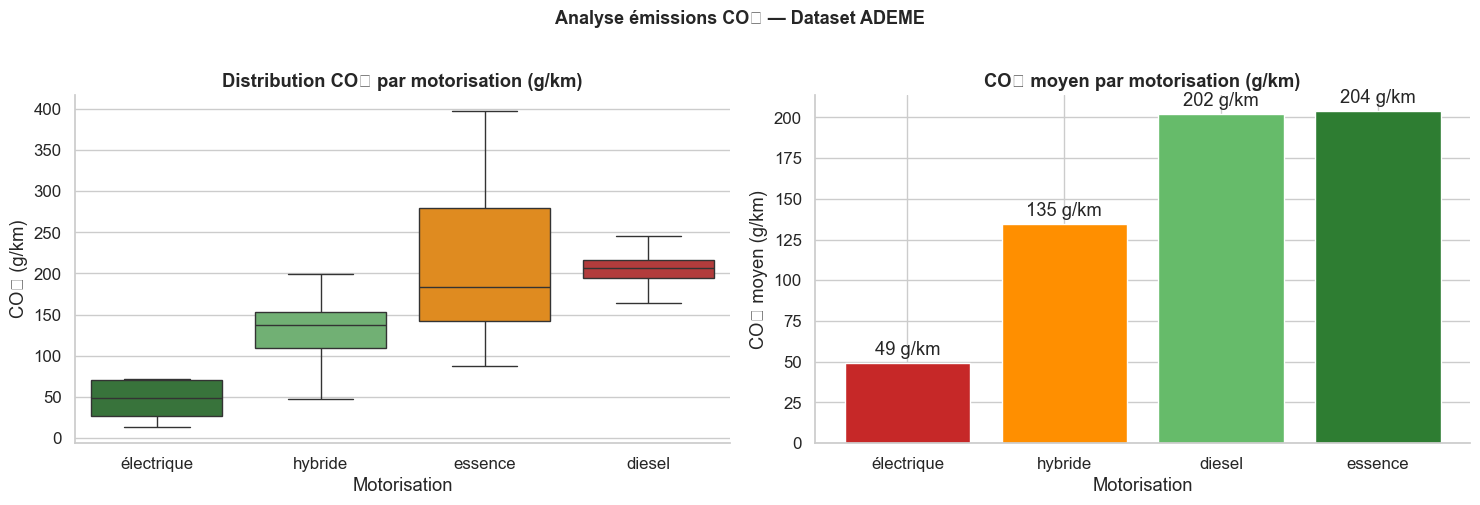

In [60]:
# ─── 2.8 Visualisation ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot CO₂ par motorisation
order = ['électrique', 'hybride', 'essence', 'diesel']
df_viz = df_ademe[df_ademe['motorisation'].isin(order)]
sns.boxplot(
    data=df_viz, x='motorisation', y='co2_gkm',
    order=order, palette=['#2e7d32','#66bb6a','#ff8f00','#c62828'],
    showfliers=False, ax=axes[0]
)
axes[0].set_title('Distribution CO₂ par motorisation (g/km)', fontweight='bold')
axes[0].set_xlabel('Motorisation')
axes[0].set_ylabel('CO₂ (g/km)')

# Barplot moyennes
emissions_moy_plot = emissions_moy.loc[emissions_moy.index.isin(order)]
colors_bar = ['#2e7d32','#66bb6a','#ff8f00','#c62828']
bars = axes[1].bar(emissions_moy_plot.index, emissions_moy_plot['moyenne'], color=colors_bar[::-1])
axes[1].bar_label(bars, fmt='%.0f g/km', padding=3)
axes[1].set_title('CO₂ moyen par motorisation (g/km)', fontweight='bold')
axes[1].set_xlabel('Motorisation')
axes[1].set_ylabel('CO₂ moyen (g/km)')

plt.suptitle('Analyse émissions CO₂ — Dataset ADEME', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [61]:
# ─── 2.9 Constantes CO₂ pour la modélisation ──────────────────────────

co2_elec    = df_ademe[df_ademe['motorisation'] == 'électrique']['co2_gkm'].mean()
co2_diesel  = df_ademe[df_ademe['motorisation'] == 'diesel']['co2_gkm'].mean()
co2_essence = df_ademe[df_ademe['motorisation'] == 'essence']['co2_gkm'].mean()

# Fallback si aucun VE dans ADEME → valeur de référence officielle ADEME 2023
CO2_VE_USAGE              = co2_elec if pd.notna(co2_elec) else 49.33
CO2_VE_FABRICATION_PAR_KM = round(12_500_000 / 150_000, 2)  # 12 500 kg / 150 000 km
CO2_VE_TOTAL              = CO2_VE_USAGE + CO2_VE_FABRICATION_PAR_KM
CO2_THERMIQUE_REEL        = 230.0  # g/km usage réel (ADEME)
GAIN_NET_PAR_KM           = CO2_THERMIQUE_REEL - CO2_VE_TOTAL
KM_SEUIL_RENTABILITE      = round(12_500_000 / (CO2_THERMIQUE_REEL - CO2_VE_USAGE))

print('━━━ CONSTANTES RETENUES POUR LA MODÉLISATION ━━━━━━━━━━━━━━━━━━━━')
print(f'  CO₂ VE usage (ADEME)     : {CO2_VE_USAGE:.2f} g/km')
print(f'  CO₂ VE fabrication       : {CO2_VE_FABRICATION_PAR_KM:.2f} g/km  (12 500 kg / 150 000 km)')
print(f'  CO₂ VE total             : {CO2_VE_TOTAL:.2f} g/km')
print(f'  CO₂ thermique réel       : {CO2_THERMIQUE_REEL:.2f} g/km')
print(f'  Gain net par km          : {GAIN_NET_PAR_KM:.2f} g/km')
print(f'  Seuil rentabilité        : {KM_SEUIL_RENTABILITE:,} km  (~{KM_SEUIL_RENTABILITE//13000} ans à 13 000 km/an)')
print(f'  Source fallback VE usage : {"ADEME mesuré" if pd.notna(co2_elec) else "ADEME référence 2023 (49.33 g/km)"}')

━━━ CONSTANTES RETENUES POUR LA MODÉLISATION ━━━━━━━━━━━━━━━━━━━━
  CO₂ VE usage (ADEME)     : 49.33 g/km
  CO₂ VE fabrication       : 83.33 g/km  (12 500 kg / 150 000 km)
  CO₂ VE total             : 132.66 g/km
  CO₂ thermique réel       : 230.00 g/km
  Gain net par km          : 97.34 g/km
  Seuil rentabilité        : 69,188 km  (~5 ans à 13 000 km/an)
  Source fallback VE usage : ADEME mesuré


In [62]:
# Export
df_ademe.to_csv(os.path.join(PREPARED_DIR, 'df_clean.csv'), index=False, encoding='utf-8')
print(f'✅ df_clean.csv exporté — {df_ademe.shape[0]:,} lignes, {df_ademe.shape[1]} colonnes')

✅ df_clean.csv exporté — 55,010 lignes, 15 colonnes


---
## 3. Dataset — Intensité carbone de l'électricité (Our World in Data)

In [63]:
# ─── 3.1 Chargement ───────────────────────────────────────────────────
df_intensite_raw = pd.read_csv(os.path.join(DATA_DIR, 'intensite_carbone.csv'))
print(f'Dimensions brutes : {df_intensite_raw.shape}')
df_intensite_raw.head(3)

Dimensions brutes : (5738, 4)


,Entity,Code,Year,co2_intensity__gco2_kwh
0,ASEAN (Ember),NaN,2000,572.85864
1,ASEAN (Ember),NaN,2001,570.60640
2,ASEAN (Ember),NaN,2002,573.02800


In [64]:
# ─── 3.2 Renommage ────────────────────────────────────────────────────
df_intensite_raw = df_intensite_raw.rename(columns={
    'Entity'                  : 'pays',
    'Code'                    : 'code_pays',
    'Year'                    : 'annee',
    'co2_intensity__gco2_kwh' : 'intensite_carbone_gco2_kwh'
})

# ─── 3.3 Filtrage France ──────────────────────────────────────────────
df_intensite_fr = (
    df_intensite_raw[df_intensite_raw['pays'].str.lower().str.contains('france', na=False)]
    [['annee', 'intensite_carbone_gco2_kwh']]
    .sort_values('annee')
    .reset_index(drop=True)
)

print(f'France : {len(df_intensite_fr)} années disponibles ({df_intensite_fr["annee"].min()}–{df_intensite_fr["annee"].max()})')
print(df_intensite_fr.tail(5).to_string())

France : 25 années disponibles (2000–2024)
    annee  intensite_carbone_gco2_kwh
20   2020                   59.080050
21   2021                   59.787445
22   2022                   78.550240
23   2023                   55.275410
24   2024                   44.179085


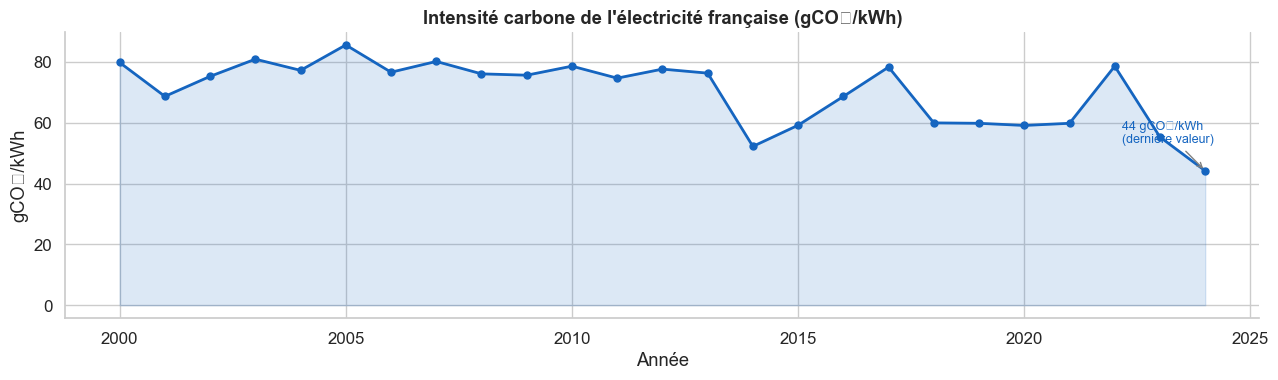

✅ df_intensite_fr.csv exporté — 25 lignes


In [65]:
# ─── 3.4 Visualisation ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(df_intensite_fr['annee'], df_intensite_fr['intensite_carbone_gco2_kwh'],
                alpha=0.15, color=COLORS['bleu'])
ax.plot(df_intensite_fr['annee'], df_intensite_fr['intensite_carbone_gco2_kwh'],
        color=COLORS['bleu'], marker='o', linewidth=2, markersize=5)
ax.set_title('Intensité carbone de l\'électricité française (gCO₂/kWh)', fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('gCO₂/kWh')
ax.annotate(f'{df_intensite_fr.iloc[-1]["intensite_carbone_gco2_kwh"]:.0f} gCO₂/kWh\n(dernière valeur)',
            xy=(df_intensite_fr.iloc[-1]['annee'], df_intensite_fr.iloc[-1]['intensite_carbone_gco2_kwh']),
            xytext=(-60, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color=COLORS['bleu'])
plt.tight_layout()
plt.show()

# Export
df_intensite_fr.to_csv(os.path.join(PREPARED_DIR, 'df_intensite_fr.csv'), index=False, encoding='utf-8')
print(f'✅ df_intensite_fr.csv exporté — {len(df_intensite_fr)} lignes')

---
## 4. Dataset — Part de marché des VE (data.gouv.fr)

In [66]:
# ─── 4.1 Chargement ───────────────────────────────────────────────────
df_part_raw = pd.read_csv(os.path.join(DATA_DIR, 'part_marche_ve.csv'), low_memory=False)
print(f'Dimensions brutes : {df_part_raw.shape[0]:,} lignes × {df_part_raw.shape[1]} colonnes')
print(f'Colonnes : {list(df_part_raw.columns)}')
df_part_raw.head(3)

Dimensions brutes : 879,106 lignes × 10 colonnes
Colonnes : ['date_mesure.year', 'geocode_region', 'libelle_region', 'geocode_departement', 'libelle_departement', 'geocode_commune', 'libelle_commune', 'categorie_vehicule', 'classe_vehicule', 'part_de_marche_des_vehicules_electriques_dans_les_immatriculations_annuelles_immatriculations_vehicules']


,date_mesure.year,geocode_region,libelle_region,geocode_departement,libelle_departement,geocode_commune,libelle_commune,categorie_vehicule,classe_vehicule,part_de_marche_des_vehicules_electriques_dans_les_immatriculations_annuelles_immatriculations_vehicules
0,2019-01-01T00:00:00.000,11,Île-de-France,92,Hauts-de-Seine,92044,LEVALLOIS PERRET,VP,vp,0.018817
1,2016-01-01T00:00:00.000,76,Occitanie,65,Hautes-Pyrénées,65456,UGLAS,VP,vp,0.000000
2,2011-01-01T00:00:00.000,75,Nouvelle-Aquitaine,17,Charente-Maritime,17111,CLION,VP,vp,0.000000


In [67]:
# ─── 4.2 Renommage — noms courts et lisibles ──────────────────────────
# La colonne part_ve a un nom de 100+ caractères → on la renomme d'abord

COLONNES_PART = {
    'date_mesure.year'  : 'date_mesure',
    'geocode_region'    : 'code_region',
    'libelle_region'    : 'region',
    'geocode_departement': 'code_dept',
    'libelle_departement': 'departement',
    'geocode_commune'   : 'code_commune',
    'libelle_commune'   : 'commune',
    'categorie_vehicule': 'categorie',
    'classe_vehicule'   : 'classe',
    # Colonne cible — nom complet OBLIGATOIRE
    'part_de_marche_des_vehicules_electriques_dans_les_immatriculations_annuelles_immatriculations_vehicules': 'part_ve'
}

# Ne renommer que les colonnes présentes
cols_presentes = {k: v for k, v in COLONNES_PART.items() if k in df_part_raw.columns}
df_part = df_part_raw.rename(columns=cols_presentes).copy()

print(f'Colonnes renommées : {len(cols_presentes)}')
print(f'Colonnes finales   : {list(df_part.columns)}')

Colonnes renommées : 10
Colonnes finales   : ['date_mesure', 'code_region', 'region', 'code_dept', 'departement', 'code_commune', 'commune', 'categorie', 'classe', 'part_ve']


In [68]:
# ─── 4.3 Audit qualité ────────────────────────────────────────────────
print('━━━ AUDIT QUALITÉ — PART MARCHÉ VE ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'Doublons         : {df_part.duplicated().sum():,}')
print(f'Valeurs manquantes :')
print(df_part.isnull().sum()[df_part.isnull().sum() > 0])

print(f'\nCatégories disponibles :')
print(df_part['categorie'].value_counts())

━━━ AUDIT QUALITÉ — PART MARCHÉ VE ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Doublons         : 12,505
Valeurs manquantes :
Series([], dtype: int64)

Catégories disponibles :
categorie
VP                   421198
CYCLOMOTEUR          130708
CAMIONNETTE          110776
MOTOCYCLETTE         101780
VOITURETTE            62283
DERIVE VP             30063
VASP LEGER             7770
TRACTEUR AGRICOLE      7323
CAMION                 3001
BUS                    1403
VASP LOURD             1136
TRACTEUR ROUTIER       1085
AUTOCAR                 484
CAMPING CAR              47
REMORQUE                 27
SEMI-REMORQUE            22
Name: count, dtype: int64


In [69]:
# ─── 4.4 Nettoyage ────────────────────────────────────────────────────
df_part = df_part.drop_duplicates()

# Extraction de l'année depuis le format ISO datetime '2019-01-01T00:00:00.000'
df_part['annee'] = pd.to_datetime(df_part['date_mesure'], errors='coerce').dt.year

# La colonne part_ve est déjà en fraction (ex: 0.018 = 1.8%)
df_part['part_ve'] = pd.to_numeric(df_part['part_ve'], errors='coerce')

print(f'Range part_ve : {df_part["part_ve"].min():.5f} – {df_part["part_ve"].max():.5f}')
print(f'Années        : {sorted(df_part["annee"].dropna().unique())}')

Range part_ve : 0.00000 – 1.00000
Années        : [np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]


In [70]:
# ─── 4.5 Filtrage VP + agrégation nationale ───────────────────────────
# On garde uniquement les Voitures Particulières
# Agrégation : moyenne nationale (toutes communes) par année

df_vp = df_part[df_part['categorie'] == 'VP'].copy()
print(f'Lignes VP : {len(df_vp):,} sur {len(df_part):,} totales')

df_part_annee = (
    df_vp
    .dropna(subset=['annee', 'part_ve'])
    .query('0 <= part_ve <= 1')
    .groupby('annee')['part_ve']
    .mean()
    .reset_index()
    .rename(columns={'part_ve': 'part_ve_nationale'})
    .sort_values('annee')
    .assign(annee=lambda x: x['annee'].astype(int))
)

print('\nPart de marché VE nationale (VP) agrégée par année :')
df_part_annee['part_ve_%'] = (df_part_annee['part_ve_nationale'] * 100).round(3)
print(df_part_annee.to_string())
df_part_annee = df_part_annee.drop(columns=['part_ve_%'])

Lignes VP : 413,901 sur 866,601 totales

Part de marché VE nationale (VP) agrégée par année :
    annee  part_ve_nationale  part_ve_%
0    2010           0.000006      0.001
1    2011           0.000211      0.021
2    2012           0.002176      0.218
3    2013           0.004352      0.435
4    2014           0.004747      0.475
5    2015           0.012981      1.298
6    2016           0.015621      1.562
7    2017           0.016483      1.648
8    2018           0.016994      1.699
9    2019           0.023419      2.342
10   2020           0.085119      8.512
11   2021           0.137146     13.715
12   2022           0.205647     20.565
13   2023           0.237567     23.757


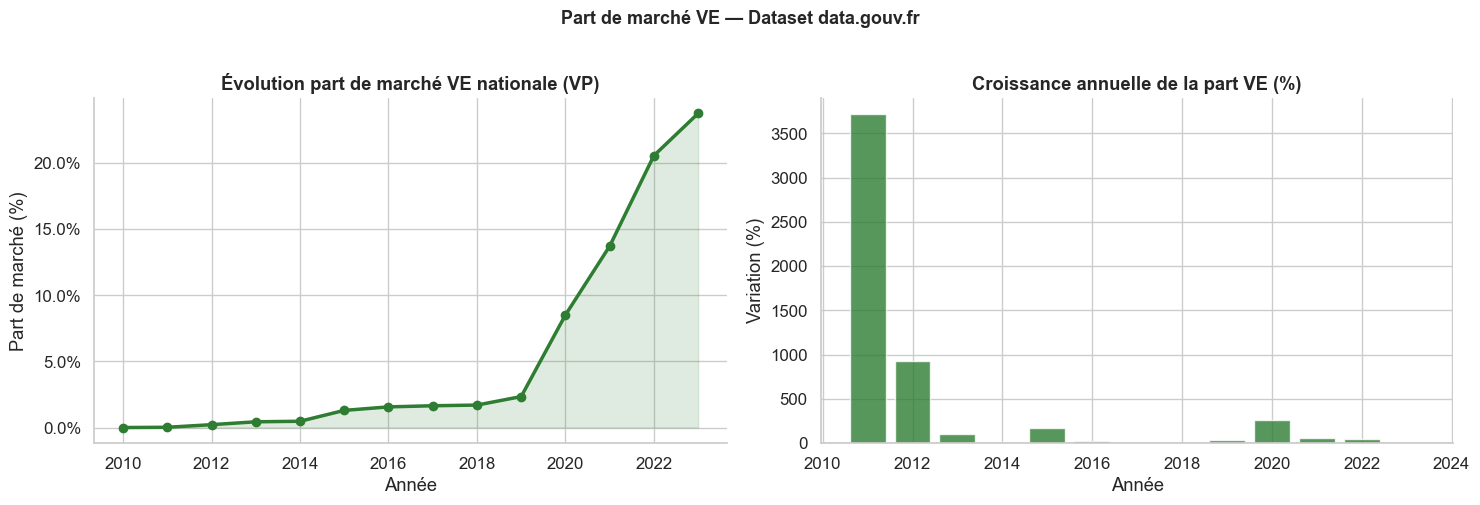

✅ df_part_annee.csv exporté — 14 années


In [71]:
# ─── 4.6 Visualisation ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Courbe temporelle
axes[0].fill_between(df_part_annee['annee'],
                      df_part_annee['part_ve_nationale'] * 100,
                      alpha=0.15, color=COLORS['vert'])
axes[0].plot(df_part_annee['annee'], df_part_annee['part_ve_nationale'] * 100,
             color=COLORS['vert'], marker='o', linewidth=2.5, markersize=6)
axes[0].set_title('Évolution part de marché VE nationale (VP)', fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Part de marché (%)')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=1))

# Croissance annuelle
df_growth = df_part_annee.copy()
df_growth['croissance'] = df_growth['part_ve_nationale'].pct_change() * 100
df_growth_clean = df_growth.dropna(subset=['croissance'])
colors_bar = [COLORS['vert'] if v >= 0 else COLORS['rouge'] for v in df_growth_clean['croissance']]
axes[1].bar(df_growth_clean['annee'], df_growth_clean['croissance'], color=colors_bar, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Croissance annuelle de la part VE (%)', fontweight='bold')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Variation (%)')

plt.suptitle('Part de marché VE — Dataset data.gouv.fr', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Export
df_part_annee.to_csv(os.path.join(PREPARED_DIR, 'df_part_annee.csv'), index=False, encoding='utf-8')
print(f'✅ df_part_annee.csv exporté — {len(df_part_annee)} années')

---
## 5. Dataset — Points de recharge (data.gouv.fr)

In [72]:
# ─── 5.1 Chargement ───────────────────────────────────────────────────
df_points_raw = pd.read_csv(os.path.join(DATA_DIR, 'points_de_charge.csv'), sep=';')
print(f'Dimensions : {df_points_raw.shape}')
df_points_raw.head()

Dimensions : (41, 4)


,trimestre,accessible_au_public,particulier,societe
0,2024 T1,127287,1089505,754839
1,2023 T2,101681,837977,599893
2,2021 T1,37491,308505,269215
3,2020 T1,31081,173740,167737
4,2019 T2,27668,124395,119576


In [73]:
# ─── 5.2 Renommage + nettoyage ────────────────────────────────────────
df_points = df_points_raw.copy()

# Extraction de l'année depuis la colonne trimestre si besoin
if 'annee' not in df_points.columns:
    df_points['annee'] = df_points['trimestre'].str[:4].astype(int)

# Calcul total si absent
if 'total_points' not in df_points.columns:
    cols_num = [c for c in df_points.select_dtypes(include=[np.number]).columns if c != 'annee']
    df_points['total_points'] = df_points[cols_num].sum(axis=1)

# Agrégation annuelle (valeur max du dernier trimestre = cumulatif)
df_points_yearly = (
    df_points.groupby('annee')['total_points']
    .max()
    .reset_index()
    .rename(columns={'total_points': 'nb_points_recharge'})
)

print('Points de recharge par année :')
print(df_points_yearly.to_string())

Points de recharge par année :
    annee  nb_points_recharge
0    2015               91723
1    2016              133490
2    2017              179076
3    2018              239361
4    2019              311814
5    2020              540993
6    2021              888772
7    2022             1265149
8    2023             1834023
9    2024             2353719
10   2025             2466716


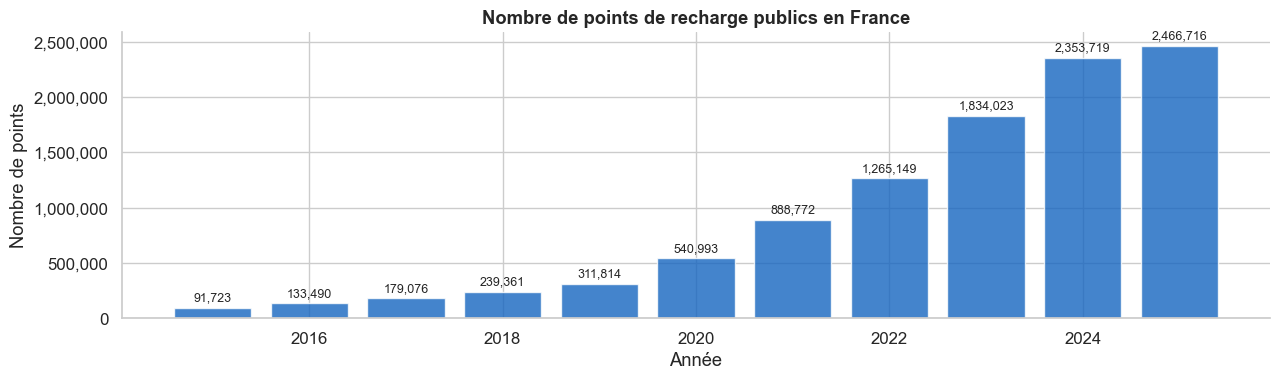

✅ df_points_yearly.csv exporté — 11 années


In [74]:
# ─── 5.3 Visualisation ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(df_points_yearly['annee'], df_points_yearly['nb_points_recharge'],
              color=COLORS['bleu'], alpha=0.8)
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.set_title('Nombre de points de recharge publics en France', fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('Nombre de points')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

# Export
df_points_yearly.to_csv(os.path.join(PREPARED_DIR, 'df_points_yearly.csv'), index=False, encoding='utf-8')
print(f'✅ df_points_yearly.csv exporté — {len(df_points_yearly)} années')

---
## 6. Fusions & Corrélations

In [75]:
# ─── 6.1 Fusions ──────────────────────────────────────────────────────

# Part VE + Intensité carbone
df_fusion = df_part_annee.merge(df_intensite_fr, on='annee', how='inner')

# Part VE + Points de recharge
df_points_part = df_part_annee.merge(df_points_yearly, on='annee', how='inner')

print(f'df_fusion        : {len(df_fusion)} années communes (part_ve + intensite_carbone)')
print(f'df_points_part   : {len(df_points_part)} années communes (part_ve + points_recharge)')

print('\ndf_fusion :')
print(df_fusion.to_string())

df_fusion        : 14 années communes (part_ve + intensite_carbone)
df_points_part   : 9 années communes (part_ve + points_recharge)

df_fusion :
    annee  part_ve_nationale  intensite_carbone_gco2_kwh
0    2010           0.000006                   78.561775
1    2011           0.000211                   74.623440
2    2012           0.002176                   77.592580
3    2013           0.004352                   76.272220
4    2014           0.004747                   52.197560
5    2015           0.012981                   59.149334
6    2016           0.015621                   68.606400
7    2017           0.016483                   78.262580
8    2018           0.016994                   59.923590
9    2019           0.023419                   59.787510
10   2020           0.085119                   59.080050
11   2021           0.137146                   59.787445
12   2022           0.205647                   78.550240
13   2023           0.237567                   55.275410

Corrélations (df_fusion) :
                            annee  part_ve_nationale  \
annee                       1.000              0.823   
part_ve_nationale           0.823              1.000   
intensite_carbone_gco2_kwh -0.453             -0.214   

                            intensite_carbone_gco2_kwh  
annee                                           -0.453  
part_ve_nationale                               -0.214  
intensite_carbone_gco2_kwh                       1.000  


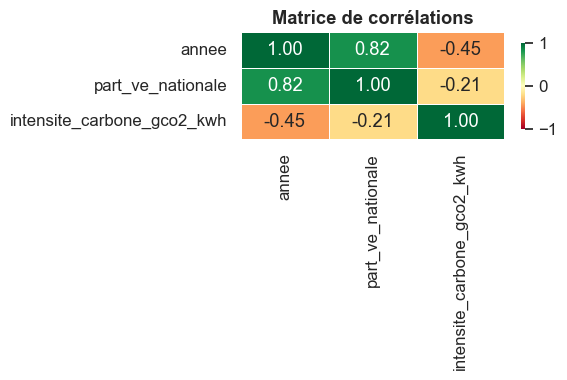

In [76]:
# ─── 6.2 Matrice de corrélations ──────────────────────────────────────
print('Corrélations (df_fusion) :')
corr = df_fusion.corr(numeric_only=True).round(3)
print(corr)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélations', fontweight='bold')
plt.tight_layout()
plt.show()

`annee ↔ part_ve = +0.823` — forte corrélation positive, logique : plus les années passent, plus les VE progressent.

`annee ↔ intensite_carbone = -0.453` — corrélation négative modérée : le réseau électrique français se décarbone progressivement avec le temps.

`part_ve ↔ intensite_carbone = -0.214` — corrélation faible. C'est normal et honnête — l'intensité carbone dépend surtout du mix énergétique national (nucléaire, renouvelables), pas directement du nombre de VE. Ces deux variables évoluent dans le même sens sur le long terme mais pas de façon mécanique.

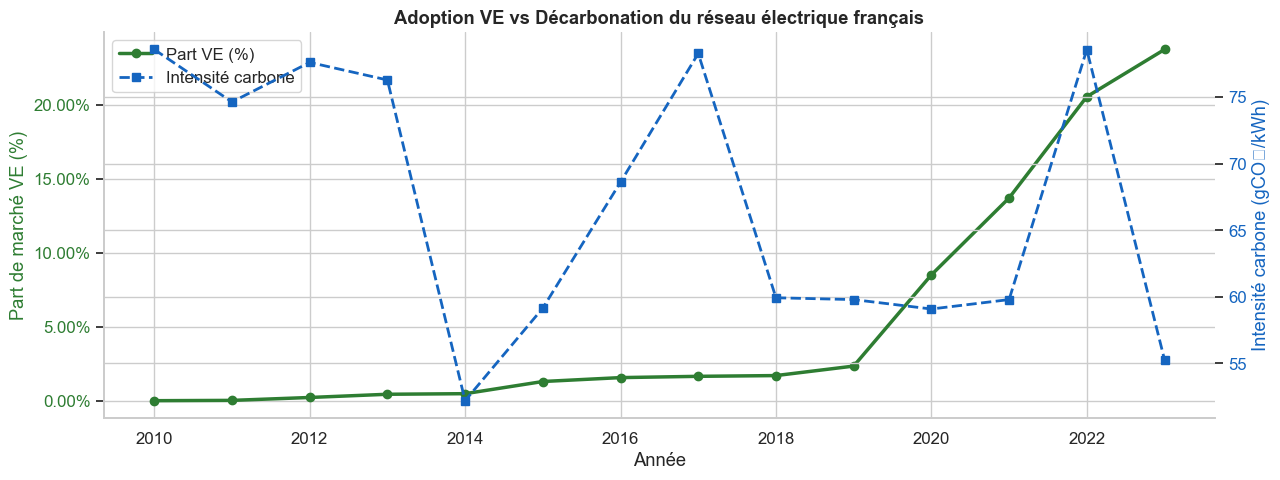

✅ df_fusion.csv et df_points_part.csv exportés


In [77]:
# ─── 6.3 Visualisation double axe ─────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(df_fusion['annee'], df_fusion['part_ve_nationale'] * 100,
         color=COLORS['vert'], marker='o', linewidth=2.5, label='Part VE (%)')
ax1.set_xlabel('Année')
ax1.set_ylabel('Part de marché VE (%)', color=COLORS['vert'])
ax1.tick_params(axis='y', labelcolor=COLORS['vert'])
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=2))

ax2 = ax1.twinx()
ax2.plot(df_fusion['annee'], df_fusion['intensite_carbone_gco2_kwh'],
         color=COLORS['bleu'], marker='s', linestyle='--', linewidth=2, label='Intensité carbone')
ax2.set_ylabel('Intensité carbone (gCO₂/kWh)', color=COLORS['bleu'])
ax2.tick_params(axis='y', labelcolor=COLORS['bleu'])

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Adoption VE vs Décarbonation du réseau électrique français', fontweight='bold')
fig.tight_layout()
plt.show()

# Exports
df_fusion.to_csv(os.path.join(PREPARED_DIR, 'df_fusion.csv'), index=False, encoding='utf-8')
df_points_part.to_csv(os.path.join(PREPARED_DIR, 'df_points_part.csv'), index=False, encoding='utf-8')
print('✅ df_fusion.csv et df_points_part.csv exportés')

---
## 7. Récapitulatif

### Datasets produits

| Fichier | Lignes | Colonnes clés | Usage |
|---|---|---|---|
| `df_clean.csv` | ~55 000 | marque, modele, motorisation, co2_gkm | Référence CO₂ VE/thermique |
| `df_intensite_fr.csv` | 25 | annee, intensite_carbone_gco2_kwh | Feature modélisation |
| `df_part_annee.csv` | 14 | annee, part_ve_nationale | **Input Prophet** |
| `df_points_yearly.csv` | ~10 | annee, nb_points_recharge | Analyse corrélatoire |
| `df_fusion.csv` | ~14 | annee, part_ve, intensite | Analyse corrélation |
| `df_points_part.csv` | ~10 | annee, part_ve, nb_points | Analyse corrélation |

### Constantes CO₂ retenues

| Paramètre | Valeur | Source |
|---|---|---|
| CO₂ VE usage | 49.33 g/km | ADEME |
| CO₂ VE fabrication | 83.33 g/km | 12 500 kg / 150 000 km |
| CO₂ thermique réel | 230 g/km | ADEME usage réel |
| Gain net | ~97 g/km | calcul |
| Seuil rentabilité | ~69 000 km | calcul |